In [5]:
import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

os.environ["MUJOCO_GL"] = "egl"
size=(64,64)

from robosuite.controllers import load_controller_config
controller_config = load_controller_config(default_controller="OSC_POSE")
controller_config["orientation_limits"] = [0, 0]

env =  suite.make(
                "Stack",
                robots="Panda",  # use Sawyer robot
                controller_configs=controller_config,
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names="agentview",
                camera_depths=True,
                camera_segmentations="element",
                camera_heights= size[0],  # image height
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )

In [4]:
from robosuite.controllers import load_controller_config
controller_config = load_controller_config(default_controller="OSC_POSE")
controller_config["orientation_limits"] = [0, 0]
print(controller_config)

{'type': 'OSC_POSE', 'input_max': 1, 'input_min': -1, 'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5], 'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5], 'kp': 150, 'damping_ratio': 1, 'impedance_mode': 'fixed', 'kp_limits': [0, 300], 'damping_ratio_limits': [0, 10], 'position_limits': None, 'orientation_limits': [0, 0], 'uncouple_pos_ori': True, 'control_delta': True, 'interpolation': None, 'ramp_ratio': 0.2}


In [1]:
from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM
import custom_robosuite_tasks

class env():
    def __init__(self, task):
        self.task = task
        self.camera = "agentview"
        self.size = (64, 64)
        self.segmentation_level = "element" 
        self.horizon = 250
        self.cube_rgba = (0, 1, 0, 1)
        self.cube_minsize = (0.05, 0.05, 0.05)

    def make(self):
        self._env = custom_robosuite_tasks.make(self.task, self)

        
robot = env("Lift")

robot.make()

# cam_mover = CM(robot._env, camera=robot.camera)
# (
#     start_cam_pos,
#     start_cam_quat,
# ) = cam_mover.get_camera_pose()

# start_cam_pos += [0.2, 0.0, 0.4]

# cam_mover.set_camera_pose(pos=start_cam_pos)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [1]:

from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

# from custom_robosuite_tasks import *

from robosuite.controllers import load_controller_config
controller_config = load_controller_config(default_controller="OSC_POSE")
controller_config["orientation_limits"] = [0, 0]


os.environ["MUJOCO_GL"] = "egl"
camera = "sideview"
size=(64,64)
spawn_range = 0.3

env = CustomLift(
                robots="Panda",  # use Sawyer robot
                controller_configs=controller_config, 
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names=camera,
                camera_depths=True,
                # render_visual_mesh=False,
                cube_minsize=(0.04, 0.04, 0.04),
                spawn_range=(-spawn_range, spawn_range),
                camera_segmentations="element",
                camera_heights= size[0],  # image h|eight
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [3]:
# move camera to agentview2 

cam_mover = CM(env, camera=camera)
(start_cam_pos, start_cam_quat) = cam_mover.get_camera_pose()
start_cam_pos += [0.2, 0.0, 0.5]

cam_mover.set_camera_pose(pos=start_cam_pos)

In [6]:
action = [0,0,0,0,0,0,0]
env_state, rew, done, info = env.step(action)

# init_qpos = [-0.3, 0.85, 0, -2.2, 0, 3, 0.75]
# env.robots[0].set_robot_joint_positions(init_qpos)
# env.robots[0].controller.update_initial_joints(init_qpos)
# env.robots[0].controller.reset_goal()

# env_state = env._get_observations(force_update=True)

def state_extraction(camera, env_state):

        rgb = env_state[camera + "_image"][::-1].transpose(2, 0, 1)
        depth = env_state[camera + "_depth"][::-1].transpose(2, 0, 1)

        # obtain world coordinates from the segmentation mask
        # depth_map = CU.get_real_depth_map(sim=self._env.sim, depth_map=depth)

        seg = env_state[
            camera + "_segmentation_" + "element"
        ][::-1].transpose(2, 0, 1)

        return  rgb, depth, seg

(3, 64, 64)


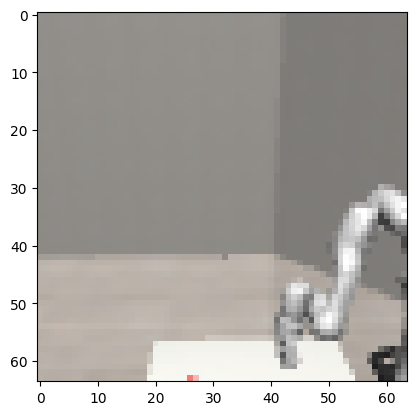

In [9]:
import matplotlib.pyplot as plt

rgb, depth, seg = state_extraction(camera, env_state)

print(rgb.shape)
plt.imshow(rgb.transpose(1,2,0))

from PIL import Image
im = Image.fromarray(rgb.transpose(1,2,0))
im.save("panda.png")

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

image = cv2.imread('panda.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [12]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))    


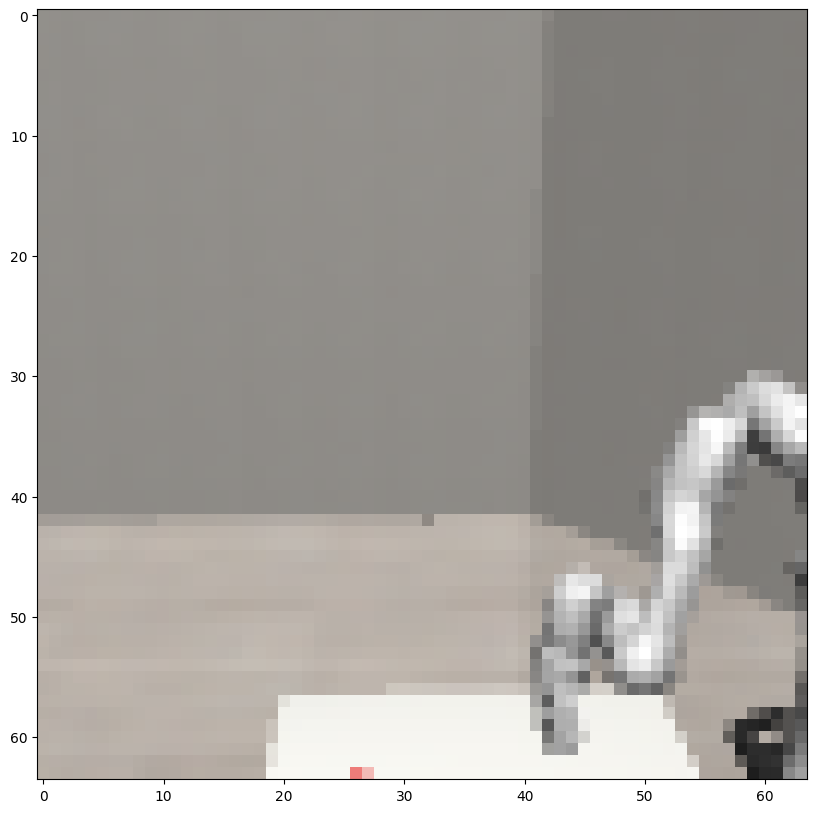

In [10]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [17]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

import sys
# !{sys.executable} -m pip install opencv-python matplotlib
# !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

# !mkdir images
# !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
# !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg

# !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

PyTorch version: 1.10.1+cu113
Torchvision version: 0.11.2+cu113
CUDA is available: True


In [22]:
import time
t1 = time.time()

predictor.set_image(image)
print("encod time= ", time.time() - t1)

encod time=  0.3049309253692627


In [24]:
input_point = np.array([[30, 46]])
input_label = np.array([1])

In [27]:
t2 = time.time()
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
print("decod time= ", time.time() - t2)


decod time=  0.009056568145751953
